# Vectors, norms, and projections

CPU companion; no accelerator is required. TPU execution not validated.

- Read a dot product geometrically and separate a vector into a projection and an orthogonal residual.
- Read length and alignment separately
- Find the closest point on a line
- Use orthogonality as an independent check
- Know when the formula is undefined

When a model multiplies features by weights, what is it measuring? Start with two arrows you can draw on paper. We will measure length, alignment and the part of one arrow that lies along the other. These ideas make regression and gradient directions easier to reason about.

## The idea

Projecting a vector onto a direction keeps the part parallel to that direction. The residual is what the direction cannot explain. This small geometric idea will reappear in least squares, gradient components and constrained updates.

## A projection explains what remains

Take $v=(3,4)$ and direction $u=(1,0)$. The projection is $(3,0)$, leaving residual $(0,4)$. Their sum recovers $v$, and the residual is perpendicular to $u$. The original norm is $5$, consistent with the right triangle.

Now replace $u$ by $(2,0)$. The direction has not changed, so the projected vector should not change. The coefficient must adjust for the direction's squared norm. Forgetting that denominator makes the result depend on an arbitrary scaling of the direction.

Read the vector figure by following the projection and then the residual to the original endpoint. Use equal axis scale: otherwise a mathematically right angle may not look right on the page.

### Pause and reason

What happens if the direction vector is zero?

<details><summary>Compare your reasoning</summary>

It defines no direction and has zero squared norm, so the usual projection formula is undefined. Reject that input or define a separate application-specific convention explicitly.

</details>

## Read length and alignment separately

Let $u=(3,4)$ and $a=(1,0)$. The length of $u$ is $5$, and $u^\mathsf{T}a=3$. The dot product is not a distance or a probability: reversing $a$ changes its sign. For nonzero vectors, dividing by both lengths gives the cosine of their angle, here $3/5$. In higher dimensions we use exactly the same sum, even when we cannot draw all the axes.

$$
\|u\|_2=\sqrt{\sum_i u_i^2},\qquad u^\mathsf{T}a=\sum_i u_i a_i
$$

## Find the closest point on a line

Points on the line through $a$ have the form $ca$, where $c$ is a scalar. Choose the point nearest $u$. Its coefficient is $c=(a^\mathsf{T}u)/(a^\mathsf{T}a)$. For our axis direction, $c=3$, so the projection is $p=(3,0)$ and the leftover is $r=u-p=(0,4)$. Notice that the coefficient depends on how long we draw $a$; the projected point does not.

$$
p=\frac{a^\mathsf{T}u}{a^\mathsf{T}a}a,\qquad r=u-p,\qquad a^\mathsf{T}r=0
$$

## Use orthogonality as an independent check

Orthogonal means perpendicular; algebraically, the dot product is zero. Because $p$ and $r$ are perpendicular, their squared lengths add to the squared length of $u$: $9+16=25$. We check both this identity and the leftover dot product. Matching a library projection to a copy of the same formula would give less independent evidence. For float32 calculations, a small absolute tolerance allows rounding near zero.

## Know when the formula is undefined

The zero vector has no direction. Projecting onto it would divide by $0$, and cosine similarity with it is also undefined. Our eager teaching helper raises a clear error for that input. A compiled application needs a separately defined policy, such as a validity mask or input validation before compilation. Adding a tiny constant silently changes the mathematical question; explain that policy if you choose it.

## Draw the two vectors

Create main.py in your activated CPU course environment. Add the vectors and verify their lengths before adding a projection.

In [1]:
# Step 1 — Draw the two vectors: The length is 5; the component along the horizontal unit direction...
# Import jax.numpy for this computation.
import jax.numpy as jnp
# Initialize array `u` with explicit values and shape.
u = jnp.array([3.0, 4.0])
# Initialize array `a` with explicit values and shape.
a = jnp.array([1.0, 0.0])
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.linalg.norm(u), 5.0)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(u, a), 3.0)

The length is $5$; the component along the horizontal unit direction is $3$.

## Build the projection

Append this eager helper. Keep the input check outside any jitted function in this exercise.

In [2]:
# Step 2 — Build the projection: The leftover r contains what the chosen direction cannot explain.
def project(u, a):
    # Run `jnp.dot` to compute `denominator`.
    denominator = jnp.dot(a, a)
    # Guard input contract (`float(denominator) == 0.0`) and fail fast if violated.
    if float(denominator) == 0.0:
        raise ValueError('Projection needs a nonzero direction')
    # Return `jnp.dot(a, u) / denominator * a` to the caller.
    return jnp.dot(a, u) / denominator * a
# Run `project` to compute `p`.
p = project(u, a)
# Evaluate `r` from the current inputs and state.
r = u - p

The leftover $r$ contains what the chosen direction cannot explain.

## Check with geometry

Append these assertions and run python main.py. Compare with your drawing before reading the experiment.

In [3]:
# Step 3 — Check with geometry: You should see [3,0] and [0,4]; the squared lengths sum to 25.
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(p, jnp.array([3.0, 0.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(a, r), 0.0, atol=1e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(p, p) + jnp.dot(r, r), jnp.dot(u, u))
# Print the observed values to compare against the expected result.
print('projection / residual:', p, r)

projection / residual: [3. 0.] [0. 4.]


You should see $[3,0]$ and $[0,4]$; the squared lengths sum to $25$.

## Run the example

In [4]:
# Step 1 — Draw the two vectors: The length is 5; the component along the horizontal unit direction...
# Import jax.numpy for this computation.
import jax.numpy as jnp
# Initialize array `u` with explicit values and shape.
u = jnp.array([3.0, 4.0])
# Initialize array `a` with explicit values and shape.
a = jnp.array([1.0, 0.0])
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(jnp.linalg.norm(u), 5.0)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(u, a), 3.0)

# Step 2 — Build the projection: The leftover r contains what the chosen direction cannot explain.
def project(u, a):
    # Run `jnp.dot` to compute `denominator`.
    denominator = jnp.dot(a, a)
    # Guard input contract (`float(denominator) == 0.0`) and fail fast if violated.
    if float(denominator) == 0.0:
        raise ValueError('Projection needs a nonzero direction')
    # Return `jnp.dot(a, u) / denominator * a` to the caller.
    return jnp.dot(a, u) / denominator * a
# Run `project` to compute `p`.
p = project(u, a)
# Evaluate `r` from the current inputs and state.
r = u - p

# Step 3 — Check with geometry: You should see [3,0] and [0,4]; the squared lengths sum to 25.
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(p, jnp.array([3.0, 0.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(a, r), 0.0, atol=1e-06)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(p, p) + jnp.dot(r, r), jnp.dot(u, u))
# Print the observed values to compare against the expected result.
print('projection / residual:', p, r)

projection / residual: [3. 0.] [0. 4.]


Expected: Projection $[3,0]$, residual $[0,4]$. Both orthogonality and the length identity pass.

## Projection and leftover form a right triangle

Predict: Which part of $(3,4)$ is explained by the horizontal direction?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Compute figure data for: Projection and leftover form a right triangle
# Evaluate `visual_data` from the current inputs and state.
visual_data = {'kind': 'vectors', 'arrows': [{'label': 'input u', 'start': [0, 0], 'end': u.tolist()}, {'label': 'projection p', 'start': [0, 0], 'end': p.tolist()}, {'label': 'residual r', 'start': p.tolist(), 'end': u.tolist()}]}

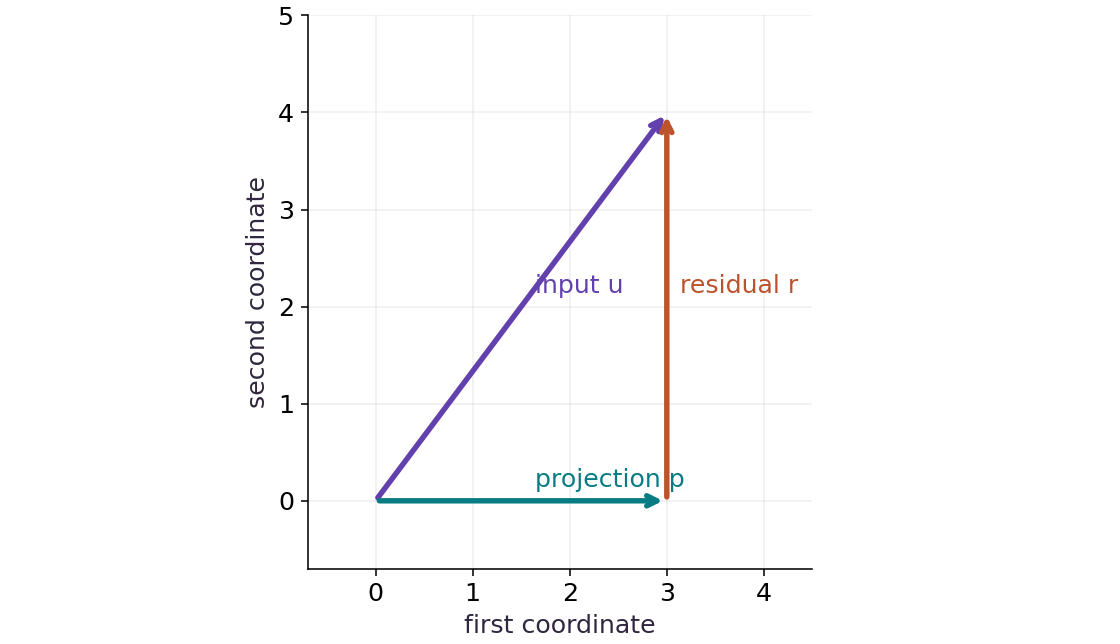

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Both axes are ordinary vector coordinates. The diagonal arrow goes from the origin to $u=(3,4)$. The horizontal arrow reaches the projection $p=(3,0)$, and the vertical arrow then goes from that point up to $u$.

Follow the horizontal and vertical arrows tip to tail: together they reproduce the diagonal arrow. Although the residual arrow is drawn starting at $(3,0)$, its displacement is $r=(0,4)$, not $(3,4)$.

### Connect it to the computation

We projected onto the horizontal direction. The residual is perpendicular to that direction, so its dot product with $(1,0)$ is zero. This right angle explains why moving the projection along the horizontal line cannot remove the remaining vertical error.

The lengths form a familiar check: $\lVert p\rVert=3$, $\lVert r\rVert=4$, and $\lVert u\rVert=5$, with $3^2+4^2=5^2$. Projection separates the part represented by the chosen direction from the part that direction cannot represent.

## Rescale the direction

Predict: If the direction becomes $2a$, does the projected point double?

In [7]:
# Experiment — Rescale the direction: A line does not change when its nonzero direction is rescaled.
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(project(u, 2 * a), p)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(project(u, -a), p)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(u, 2 * a), 2 * jnp.dot(u, a))

Expected: The projection stays fixed; the raw dot product doubles.

A line does not change when its nonzero direction is rescaled. A dot product alone does change.

## Rotate the line

Predict: For $a=(1,1)$, predict the projection coefficient and leftover.

In [8]:
# Experiment — Rotate the line: Changing direction changes what can be explained; merely...
# Initialize array `diagonal` with explicit values and shape.
diagonal = jnp.array([1.0, 1.0])
# Run `project` to compute `p2`.
p2 = project(u, diagonal)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(p2, jnp.array([3.5, 3.5]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(diagonal, u - p2), 0.0, atol=1e-06)

Expected: Projection $[3.5,3.5]$, residual $[-0.5,0.5]$.

Changing direction changes what can be explained; merely changing its length does not.

## Your exercise

Project $u=(2,-1,2)$ onto $a=(1,0,1)$. Check the residual by hand first.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `u3` with explicit values and shape.
2. Initialize array `a3` with explicit values and shape.
3. Run `project` to compute `p3`.
4. Verify that the numerical values match the expected reference within tolerance.
5. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Project u=(2,-1,2) onto a=(1,0,1).
# Initialize array `u3` with explicit values and shape.
u3 = jnp.array(...)  # TODO: compute u3
# Initialize array `a3` with explicit values and shape.
a3 = jnp.array(...)  # TODO: compute a3
# Run `project` to compute `p3`.
p3 = project(...)  # TODO: compute p3
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(p3, jnp.array([2.0, 0.0, 2.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(a3, u3 - p3), 0.0)  # TODO: complete assertion check
```

In [9]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Project u=(2,-1,2) onto a=(1,0,1).
# Initialize array `u3` with explicit values and shape.
# u3 = jnp.array(...)  # TODO: compute u3
# Initialize array `a3` with explicit values and shape.
# a3 = jnp.array(...)  # TODO: compute a3
# Run `project` to compute `p3`.
# p3 = project(...)  # TODO: compute p3
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(p3, jnp.array([2.0, 0.0, 2.0]))  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert jnp.allclose(jnp.dot(a3, u3 - p3), 0.0)  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [10]:
# Exercise solution: Project u=(2,-1,2) onto a=(1,0,1).
# Initialize array `u3` with explicit values and shape.
u3 = jnp.array([2.0, -1.0, 2.0])
# Initialize array `a3` with explicit values and shape.
a3 = jnp.array([1.0, 0.0, 1.0])
# Run `project` to compute `p3`.
p3 = project(u3, a3)
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(p3, jnp.array([2.0, 0.0, 2.0]))
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert jnp.allclose(jnp.dot(a3, u3 - p3), 0.0)

## Handle an undefined direction · Transfer / diagnosis

Show that a zero direction produces a clear input error instead of a misleading projection.

Hint: Use a try/except block; a silent successful result should fail the check.

### How to write: Handle an undefined direction — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `direction(...)` — Call `direction` with your updated parameters or inputs from this lesson's workspace.
- `project(...)` — Call `project` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Run the boundary check and catch the expected exception:

**Starter code scaffold (fill in the TODOs):**

```python
# Handle an undefined direction (Transfer / diagnosis): Rejecting an undefined input is part of the function contract.
# Run the boundary check and catch the expected exception:
try:
    project(u, jnp.zeros_like(a))
except ValueError as exc:
    assert 'nonzero'  # TODO: complete assertion check
else:
    raise AssertionError('Zero direction was accepted')
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Handle an undefined direction (Transfer / diagnosis): Rejecting an undefined input is part of the function contract.
# Run the boundary check and catch the expected exception:
# try:
#     project(u, jnp.zeros_like(a))
# except ValueError as exc:
#     assert 'nonzero'  # TODO: complete assertion check
# else:
#     raise AssertionError('Zero direction was accepted')

## Reference reasoning

Rejecting an undefined input is part of the function contract.

In [12]:
# Handle an undefined direction (Transfer / diagnosis): Rejecting an undefined input is part of the function contract.
# Run the boundary check and catch the expected exception:
try:
    project(u, jnp.zeros_like(a))
except ValueError as exc:
    assert 'nonzero' in str(exc)
else:
    raise AssertionError('Zero direction was accepted')

## Use two perpendicular directions · Transfer / diagnosis

Reconstruct $u$ from projections onto $(1,1)$ and $(1,-1)$. Would adding independent projections still work for arbitrary nonorthogonal directions?

Hint: Check the directions have zero dot product. Nonorthogonal directions can count the same component twice.

### How to write: Use two perpendicular directions — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.array(values, dtype=...)` — Constructs an immutable device-backed JAX array from Python/NumPy values.
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Initialize array `a1` with explicit values and shape.
2. Initialize array `a2` with explicit values and shape.
3. Verify that the numerical values match the expected reference within tolerance.
4. Verify that the output satisfies the expected shape, finite-value, or numerical contract.

**Starter code scaffold (fill in the TODOs):**

```python
# Use two perpendicular directions (Transfer / diagnosis): Adding separate projections reconstructs a vector in an...
# Initialize array `a1` with explicit values and shape.
a1 = jnp.array(...)  # TODO: compute a1
# Initialize array `a2` with explicit values and shape.
a2 = jnp.array(...)  # TODO: compute a2
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(project(u, a1) + project(u, a2), u)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.allclose(project(u, a) + project(u, a1), u)  # TODO: complete assertion check
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Use two perpendicular directions (Transfer / diagnosis): Adding separate projections reconstructs a vector in an...
# Initialize array `a1` with explicit values and shape.
# a1 = jnp.array(...)  # TODO: compute a1
# Initialize array `a2` with explicit values and shape.
# a2 = jnp.array(...)  # TODO: compute a2
# Verify that the numerical values match the expected reference within tolerance.
# assert jnp.allclose(project(u, a1) + project(u, a2), u)  # TODO: complete assertion check
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
# assert not jnp.allclose(project(u, a) + project(u, a1), u)  # TODO: complete assertion check

## Reference reasoning

Adding separate projections reconstructs a vector in an orthogonal basis. Correlated feature directions require a joint least-squares solve.

In [14]:
# Use two perpendicular directions (Transfer / diagnosis): Adding separate projections reconstructs a vector in an...
# Initialize array `a1` with explicit values and shape.
a1 = jnp.array([1.0, 1.0])
# Initialize array `a2` with explicit values and shape.
a2 = jnp.array([1.0, -1.0])
# Verify that the numerical values match the expected reference within tolerance.
assert jnp.allclose(project(u, a1) + project(u, a2), u)
# Verify that the output satisfies the expected shape, finite-value, or numerical contract.
assert not jnp.allclose(project(u, a) + project(u, a1), u)

## Checkpoint

Does doubling a nonzero direction double the projection onto its line?

1. Yes, because the dot product doubles
2. No; the coefficient and direction rescale in opposite ways
3. Only when the vectors are perpendicular

## Diagnose

If the leftover is not perpendicular, check the denominator: it is $a^\mathsf{T}a$, not the length of $a$. If cosine exceeds its expected range, check normalization and rounding; first reject zero-length inputs.

## Evidence

Keep the hand-computed projection, perpendicular-residual check, rescaling experiment, zero-direction repair and changed-basis calculation.

## Carry forward

- A line does not change when its nonzero direction is rescaled. A dot product alone does change.
- Changing direction changes what can be explained; merely changing its length does not.

## Primary references

- [JAX vector norms](https://docs.jax.dev/en/latest/_autosummary/jax.numpy.linalg.norm.html)
- [MIT: projections and least squares](https://ocw.mit.edu/courses/18-06-linear-algebra-spring-2010/resources/lecture-16-projection-matrices-and-least-squares/)